<a href="https://colab.research.google.com/github/Zamorano86/UFRJ_MESTRADO_ENG_NAVAL/blob/main/Lista1_Acustica_Submarina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Lista 1 - Acústica Submarina
# Configuração inicial do ambiente
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configuração dos gráficos
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [2]:
from google.colab import files

print("Selecione TODOS os arquivos baixados do BNDO.")
uploaded = files.upload()

Selecione TODOS os arquivos baixados do BNDO.


Saving Costa Norte 2025 Ant_Read_meares to Costa Norte 2025 Ant_Read_meares
Saving Costa Norte 2025 Antares to Costa Norte 2025 Antares
Saving Nordeste Cruzeiro do Sul to Nordeste Cruzeiro do Sul
Saving Nordeste Cruzeiro do_Read_me Sul to Nordeste Cruzeiro do_Read_me Sul
Saving Oceano S_Read_meul V to Oceano S_Read_meul V
Saving Oceano Sud_Read_meeste to Oceano Sud_Read_meeste
Saving Oceano Sudeste to Oceano Sudeste
Saving Oceano Sul V to Oceano Sul V


In [3]:
print("Arquivos recebidos:\n")

for nome in uploaded.keys():
    print(nome)

Arquivos recebidos:

Costa Norte 2025 Ant_Read_meares
Costa Norte 2025 Antares
Nordeste Cruzeiro do Sul
Nordeste Cruzeiro do_Read_me Sul
Oceano S_Read_meul V
Oceano Sud_Read_meeste
Oceano Sudeste
Oceano Sul V


In [4]:
# ============================================================
# Montar o Google Drive
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
# ============================================================
# Criar pasta permanente do projeto no Google Drive
# ============================================================

import os

PASTA_PROJETO = "/content/drive/MyDrive/Acustica_Submarina/Lista_1"
PASTA_BRUTOS = os.path.join(PASTA_PROJETO, "dados_brutos")
PASTA_PROCESSADOS = os.path.join(PASTA_PROJETO, "dados_processados")
PASTA_FIGURAS = os.path.join(PASTA_PROJETO, "figuras")

os.makedirs(PASTA_BRUTOS, exist_ok=True)
os.makedirs(PASTA_PROCESSADOS, exist_ok=True)
os.makedirs(PASTA_FIGURAS, exist_ok=True)

print("Pastas criadas:")
print(PASTA_BRUTOS)
print(PASTA_PROCESSADOS)
print(PASTA_FIGURAS)

Pastas criadas:
/content/drive/MyDrive/Acustica_Submarina/Lista_1/dados_brutos
/content/drive/MyDrive/Acustica_Submarina/Lista_1/dados_processados
/content/drive/MyDrive/Acustica_Submarina/Lista_1/figuras


In [6]:
# ============================================================
# Copiar os arquivos temporários do Colab para o Google Drive
# ============================================================

import os
import shutil

arquivos_copiados = []

for nome in uploaded.keys():
    origem = f"/content/{nome}"
    destino = os.path.join(PASTA_BRUTOS, nome)

    if os.path.exists(origem):
        shutil.copy2(origem, destino)
        arquivos_copiados.append(nome)
        print(f"Copiado: {nome}")
    else:
        print(f"Não encontrado no ambiente: {nome}")

print(f"\nTotal copiado: {len(arquivos_copiados)} arquivo(s).")

Copiado: Costa Norte 2025 Ant_Read_meares
Copiado: Costa Norte 2025 Antares
Copiado: Nordeste Cruzeiro do Sul
Copiado: Nordeste Cruzeiro do_Read_me Sul
Copiado: Oceano S_Read_meul V
Copiado: Oceano Sud_Read_meeste
Copiado: Oceano Sudeste
Copiado: Oceano Sul V

Total copiado: 8 arquivo(s).


In [7]:
# ============================================================
# Conferir os arquivos salvos e seus tamanhos
# ============================================================

for nome in sorted(os.listdir(PASTA_BRUTOS)):
    caminho = os.path.join(PASTA_BRUTOS, nome)
    tamanho_mb = os.path.getsize(caminho) / (1024 ** 2)

    print(f"{nome:<50} {tamanho_mb:10.2f} MB")

Costa Norte 2025 Ant_Read_meares                         0.00 MB
Costa Norte 2025 Antares                               116.68 MB
Nordeste Cruzeiro do Sul                               143.48 MB
Nordeste Cruzeiro do_Read_me Sul                         0.00 MB
Oceano S_Read_meul V                                     0.00 MB
Oceano Sud_Read_meeste                                   0.00 MB
Oceano Sudeste                                          49.44 MB
Oceano Sul V                                            21.02 MB


In [8]:
# ============================================================
# Inspecionar o tipo real dos arquivos brutos
# ============================================================

import os
import subprocess

for nome in sorted(os.listdir(PASTA_BRUTOS)):
    caminho = os.path.join(PASTA_BRUTOS, nome)
    tamanho = os.path.getsize(caminho)

    resultado = subprocess.run(
        ["file", "-b", caminho],
        capture_output=True,
        text=True
    ).stdout.strip()

    print("=" * 80)
    print(f"Arquivo: {nome}")
    print(f"Tamanho: {tamanho:,} bytes")
    print(f"Tipo identificado: {resultado}")

Arquivo: Costa Norte 2025 Ant_Read_meares
Tamanho: 557 bytes
Tipo identificado: Unicode text, UTF-8 text
Arquivo: Costa Norte 2025 Antares
Tamanho: 122,346,393 bytes
Tipo identificado: Unicode text, UTF-8 text, with very long lines (660)
Arquivo: Nordeste Cruzeiro do Sul
Tamanho: 150,445,690 bytes
Tipo identificado: Unicode text, UTF-8 text, with very long lines (569)
Arquivo: Nordeste Cruzeiro do_Read_me Sul
Tamanho: 557 bytes
Tipo identificado: Unicode text, UTF-8 text
Arquivo: Oceano S_Read_meul V
Tamanho: 557 bytes
Tipo identificado: Unicode text, UTF-8 text
Arquivo: Oceano Sud_Read_meeste
Tamanho: 557 bytes
Tipo identificado: Unicode text, UTF-8 text
Arquivo: Oceano Sudeste
Tamanho: 51,839,562 bytes
Tipo identificado: Unicode text, UTF-8 text, with very long lines (569)
Arquivo: Oceano Sul V
Tamanho: 22,046,098 bytes
Tipo identificado: Unicode text, UTF-8 text, with very long lines (569)


In [9]:
# ============================================================
# Ler os arquivos pequenos de instruções
# ============================================================

arquivos_pequenos = []

for nome in sorted(os.listdir(PASTA_BRUTOS)):
    caminho = os.path.join(PASTA_BRUTOS, nome)

    if os.path.getsize(caminho) < 10_000:
        arquivos_pequenos.append(nome)

        print("=" * 90)
        print(f"ARQUIVO: {nome}")
        print("=" * 90)

        with open(caminho, "r", encoding="utf-8", errors="replace") as arquivo:
            conteudo = arquivo.read()

        print(conteudo)
        print()

print(f"Total de arquivos de instruções encontrados: {len(arquivos_pequenos)}")

ARQUIVO: Costa Norte 2025 Ant_Read_meares

CONTROLE DE QUALIDADE

Primeiro dígito corresponde ao QC do BNDO, o segundo ao QC estabelecido pela origem(convertido para o QC BNDO) e o terceiro informa se o dado foi verificado ( 0 -> não qualificado, 1 -> apenas origem e 2 -> pelo CHM).
Valor de qualificação do dado resultante da analise assumindo os seguintes valores: 
0- sem qualidade;
1- sem qualidade, pre-processado por software do equipamento;
2- correto;3- inconsistente; 
4- duvidoso; 
5- alterado (interpolação); 
6- alterado por inferência;
7- característica especial;
9- sem valor.

ARQUIVO: Nordeste Cruzeiro do_Read_me Sul

CONTROLE DE QUALIDADE

Primeiro dígito corresponde ao QC do BNDO, o segundo ao QC estabelecido pela origem(convertido para o QC BNDO) e o terceiro informa se o dado foi verificado ( 0 -> não qualificado, 1 -> apenas origem e 2 -> pelo CHM).
Valor de qualificação do dado resultante da analise assumindo os seguintes valores: 
0- sem qualidade;
1- sem qualidade, pr

In [10]:
# ============================================================
# Inspecionar as primeiras linhas dos arquivos grandes
# sem carregar os arquivos completos
# ============================================================

arquivos_grandes = []

for nome in sorted(os.listdir(PASTA_BRUTOS)):
    caminho = os.path.join(PASTA_BRUTOS, nome)

    if os.path.getsize(caminho) >= 10_000:
        arquivos_grandes.append(nome)

        print("\n" + "=" * 100)
        print(f"ARQUIVO: {nome}")
        print("=" * 100)

        with open(caminho, "r", encoding="utf-8", errors="replace") as arquivo:
            for numero_linha in range(8):
                linha = arquivo.readline()

                if not linha:
                    break

                # repr() permite visualizar tabulações, vírgulas,
                # ponto e vírgula e outros caracteres separadores.
                print(f"Linha {numero_linha + 1}:")
                print(repr(linha[:1500]))
                print()

print(f"Total de arquivos grandes encontrados: {len(arquivos_grandes)}")


ARQUIVO: Costa Norte 2025 Antares
Linha 1:
'Data-Hora;CTQC_Data-Hora;Longitude [deg];Latitude [deg];CTQC_Posicao;Profundidade [m]; CTQC_Profundidade;Pressão [db];QC_Pressão [Flag];Pressão [Análise];Temperatura [°c];QC_Temperatura [Flag];Temperatura [Análise];Salinidade [psu];QC_Salinidade [Flag];Salinidade [Análise];Condutividade [S/m];QC_Condutividade [Flag];Condutividade [Análise];Velocidade do som [m/s];QC_Velocidade do som [Flag];Velocidade do som [Análise];Densidade ro [kg/m³];QC_Densidade ro [Flag];Densidade ro [Análise];Temperatura Potencial [°C];QC_Temperatura Potencial [Flag];Temperatura Potencial [Análise];Equipamento;Plataforma;Comissão;Projeto;Mídia;Obs_Comissão;Obs_estação;Obs_Mídia\n'

Linha 2:
'2025-10-09 04:26:47;000;-047.2858;+01.9064;000;5.2;000;5.229;000;<SerialNumber>1577, <CalibrationDate>31-May-24.;27.28170;000;Sensor Primario: <SerialNumber>6822, <CalibrationDate>06-Jun-24. Sensor Secundario: <SerialNumber>6913, <CalibrationDate>14-jun-24.;36.12620;000;None;None

In [11]:
# ============================================================
# Tentar identificar automaticamente o separador dos dados
# ============================================================

import csv

separadores_detectados = {}

for nome in arquivos_grandes:
    caminho = os.path.join(PASTA_BRUTOS, nome)

    print("\n" + "=" * 100)
    print(f"ARQUIVO: {nome}")
    print("=" * 100)

    with open(caminho, "r", encoding="utf-8", errors="replace") as arquivo:
        amostra = arquivo.read(50_000)

    try:
        dialeto = csv.Sniffer().sniff(
            amostra,
            delimiters=[",", ";", "\t", "|", " "]
        )

        separador = dialeto.delimiter
        separadores_detectados[nome] = separador

        print(f"Separador detectado: {repr(separador)}")

    except csv.Error:
        separadores_detectados[nome] = None
        print("O separador não pôde ser identificado automaticamente.")
        print("O arquivo pode possuir largura fixa ou cabeçalho especial.")


ARQUIVO: Costa Norte 2025 Antares
Separador detectado: ';'

ARQUIVO: Nordeste Cruzeiro do Sul
Separador detectado: ';'

ARQUIVO: Oceano Sudeste
Separador detectado: ';'

ARQUIVO: Oceano Sul V
Separador detectado: ';'


In [12]:
# ============================================================
# Testar a leitura dos quatro arquivos com pandas
# Apenas cinco linhas de cada arquivo
# ============================================================

amostras = {}

for nome in arquivos_grandes:
    caminho = os.path.join(PASTA_BRUTOS, nome)

    print("\n" + "=" * 100)
    print(f"ARQUIVO: {nome}")
    print("=" * 100)

    df_teste = pd.read_csv(
        caminho,
        sep=";",
        encoding="utf-8",
        na_values=["None"],
        keep_default_na=True,
        nrows=5,
        low_memory=False
    )

    # Remove espaços acidentais no início/fim dos nomes
    df_teste.columns = df_teste.columns.str.strip()

    amostras[nome] = df_teste

    print(f"Linhas lidas: {len(df_teste)}")
    print(f"Número de colunas: {len(df_teste.columns)}")
    print("\nColunas:")

    for i, coluna in enumerate(df_teste.columns, start=1):
        print(f"{i:02d}. {coluna}")

    print("\nAmostra das variáveis principais:")

    colunas_principais = [
        "Data-Hora",
        "Longitude [deg]",
        "Latitude [deg]",
        "Profundidade [m]",
        "Pressão [db]",
        "Temperatura [°c]",
        "Salinidade [psu]",
        "Condutividade [S/m]",
        "Velocidade do som [m/s]",
        "Densidade ro [kg/m³]",
        "Temperatura Potencial [°C]"
    ]

    existentes = [
        coluna for coluna in colunas_principais
        if coluna in df_teste.columns
    ]

    display(df_teste[existentes].head())


ARQUIVO: Costa Norte 2025 Antares
Linhas lidas: 5
Número de colunas: 36

Colunas:
01. Data-Hora
02. CTQC_Data-Hora
03. Longitude [deg]
04. Latitude [deg]
05. CTQC_Posicao
06. Profundidade [m]
07. CTQC_Profundidade
08. Pressão [db]
09. QC_Pressão [Flag]
10. Pressão [Análise]
11. Temperatura [°c]
12. QC_Temperatura [Flag]
13. Temperatura [Análise]
14. Salinidade [psu]
15. QC_Salinidade [Flag]
16. Salinidade [Análise]
17. Condutividade [S/m]
18. QC_Condutividade [Flag]
19. Condutividade [Análise]
20. Velocidade do som [m/s]
21. QC_Velocidade do som [Flag]
22. Velocidade do som [Análise]
23. Densidade ro [kg/m³]
24. QC_Densidade ro [Flag]
25. Densidade ro [Análise]
26. Temperatura Potencial [°C]
27. QC_Temperatura Potencial [Flag]
28. Temperatura Potencial [Análise]
29. Equipamento
30. Plataforma
31. Comissão
32. Projeto
33. Mídia
34. Obs_Comissão
35. Obs_estação
36. Obs_Mídia

Amostra das variáveis principais:


,Data-Hora,Longitude [deg],Latitude [deg],Profundidade [m],Pressão [db],Temperatura [°c],Salinidade [psu],Condutividade [S/m],Velocidade do som [m/s],Densidade ro [kg/m³],Temperatura Potencial [°C]
0,2025-10-09 04:26:47,-47.2858,1.9064,5.2,5.229,27.2817,36.1262,NaN,NaN,1023.4981,27.2805
1,2025-10-09 04:26:47,-47.2858,1.9064,5.3,5.329,27.2829,36.1261,NaN,NaN,1023.4980,27.2817
2,2025-10-09 04:26:47,-47.2858,1.9064,5.4,5.430,27.2834,36.1261,NaN,NaN,1023.4983,27.2821
3,2025-10-09 04:26:47,-47.2858,1.9064,5.5,5.530,27.2836,36.1262,NaN,NaN,1023.4988,27.2823
4,2025-10-09 04:26:47,-47.2858,1.9064,5.6,5.631,27.2837,36.1262,NaN,NaN,1023.4991,27.2824



ARQUIVO: Nordeste Cruzeiro do Sul
Linhas lidas: 5
Número de colunas: 33

Colunas:
01. Data-Hora
02. CTQC_Data-Hora
03. Longitude [deg]
04. Latitude [deg]
05. CTQC_Posicao
06. Profundidade [m]
07. CTQC_Profundidade
08. Temperatura [°c]
09. QC_Temperatura [Flag]
10. Temperatura [Análise]
11. Salinidade [psu]
12. QC_Salinidade [Flag]
13. Salinidade [Análise]
14. Condutividade [S/m]
15. QC_Condutividade [Flag]
16. Condutividade [Análise]
17. Densidade ro [kg/m³]
18. QC_Densidade ro [Flag]
19. Densidade ro [Análise]
20. Velocidade do som [m/s]
21. QC_Velocidade do som [Flag]
22. Velocidade do som [Análise]
23. Pressão [db]
24. QC_Pressão [Flag]
25. Pressão [Análise]
26. Equipamento
27. Plataforma
28. Comissão
29. Projeto
30. Mídia
31. Obs_Comissão
32. Obs_estação
33. Obs_Mídia

Amostra das variáveis principais:


,Data-Hora,Longitude [deg],Latitude [deg],Profundidade [m],Pressão [db],Temperatura [°c],Salinidade [psu],Condutividade [S/m],Velocidade do som [m/s],Densidade ro [kg/m³]
0,2025-03-26 12:13:35,-36.7533,-4.6531,4.0,NaN,28.8504,36.1016,NaN,NaN,NaN
1,2025-03-26 12:13:35,-36.7533,-4.6531,5.0,NaN,28.8526,36.1011,NaN,NaN,NaN
2,2025-03-26 12:13:35,-36.7533,-4.6531,6.0,NaN,28.8538,36.1015,NaN,NaN,NaN
3,2025-03-26 12:13:35,-36.7533,-4.6531,7.0,NaN,28.8543,36.1015,NaN,NaN,NaN
4,2025-03-26 12:13:35,-36.7533,-4.6531,8.0,NaN,28.8574,36.1016,NaN,NaN,NaN



ARQUIVO: Oceano Sudeste
Linhas lidas: 5
Número de colunas: 33

Colunas:
01. Data-Hora
02. CTQC_Data-Hora
03. Longitude [deg]
04. Latitude [deg]
05. CTQC_Posicao
06. Profundidade [m]
07. CTQC_Profundidade
08. Pressão [db]
09. QC_Pressão [Flag]
10. Pressão [Análise]
11. Temperatura [°c]
12. QC_Temperatura [Flag]
13. Temperatura [Análise]
14. Salinidade [psu]
15. QC_Salinidade [Flag]
16. Salinidade [Análise]
17. Condutividade [S/m]
18. QC_Condutividade [Flag]
19. Condutividade [Análise]
20. Densidade ro [kg/m³]
21. QC_Densidade ro [Flag]
22. Densidade ro [Análise]
23. Velocidade do som [m/s]
24. QC_Velocidade do som [Flag]
25. Velocidade do som [Análise]
26. Equipamento
27. Plataforma
28. Comissão
29. Projeto
30. Mídia
31. Obs_Comissão
32. Obs_estação
33. Obs_Mídia

Amostra das variáveis principais:


,Data-Hora,Longitude [deg],Latitude [deg],Profundidade [m],Pressão [db],Temperatura [°c],Salinidade [psu],Condutividade [S/m],Velocidade do som [m/s],Densidade ro [kg/m³]
0,2002-10-19 19:15:00,-35.2244,-22.2128,3.976,4.0,NaN,NaN,5.517586,NaN,NaN
1,2002-10-19 19:15:00,-35.2244,-22.2128,4.963,5.0,NaN,NaN,5.516870,NaN,NaN
2,2002-10-19 19:15:00,-35.2244,-22.2128,5.967,6.0,NaN,NaN,5.516810,NaN,NaN
3,2002-10-19 19:15:00,-35.2244,-22.2128,6.943,7.0,NaN,NaN,5.517792,NaN,NaN
4,2002-10-19 19:15:00,-35.2244,-22.2128,7.951,8.0,NaN,NaN,5.517831,NaN,NaN



ARQUIVO: Oceano Sul V
Linhas lidas: 5
Número de colunas: 33

Colunas:
01. Data-Hora
02. CTQC_Data-Hora
03. Longitude [deg]
04. Latitude [deg]
05. CTQC_Posicao
06. Profundidade [m]
07. CTQC_Profundidade
08. Pressão [db]
09. QC_Pressão [Flag]
10. Pressão [Análise]
11. Temperatura [°c]
12. QC_Temperatura [Flag]
13. Temperatura [Análise]
14. Salinidade [psu]
15. QC_Salinidade [Flag]
16. Salinidade [Análise]
17. Condutividade [S/m]
18. QC_Condutividade [Flag]
19. Condutividade [Análise]
20. Densidade ro [kg/m³]
21. QC_Densidade ro [Flag]
22. Densidade ro [Análise]
23. Velocidade do som [m/s]
24. QC_Velocidade do som [Flag]
25. Velocidade do som [Análise]
26. Equipamento
27. Plataforma
28. Comissão
29. Projeto
30. Mídia
31. Obs_Comissão
32. Obs_estação
33. Obs_Mídia

Amostra das variáveis principais:


,Data-Hora,Longitude [deg],Latitude [deg],Profundidade [m],Pressão [db],Temperatura [°c],Salinidade [psu],Condutividade [S/m],Velocidade do som [m/s],Densidade ro [kg/m³]
0,2018-04-10 14:19:51,-47.0833,-28.6836,8.0,8.070,NaN,NaN,5.635414,1540.0,1023.4917
1,2018-04-10 14:19:51,-47.0833,-28.6836,9.0,9.060,NaN,NaN,5.633574,1539.9,1023.5010
2,2018-04-10 14:19:51,-47.0833,-28.6836,10.0,10.069,NaN,NaN,5.632256,1539.9,1023.5088
3,2018-04-10 14:19:51,-47.0833,-28.6836,11.0,11.075,NaN,NaN,5.630922,1539.9,1023.5168
4,2018-04-10 14:19:51,-47.0833,-28.6836,12.0,12.081,NaN,NaN,5.628969,1539.9,1023.5266


In [13]:
# ============================================================
# Verificar a disponibilidade das variáveis em cada arquivo
# Leitura por blocos para economizar memória
# ============================================================

variaveis_interesse = [
    "Data-Hora",
    "Longitude [deg]",
    "Latitude [deg]",
    "Profundidade [m]",
    "Pressão [db]",
    "Temperatura [°c]",
    "Salinidade [psu]",
    "Condutividade [S/m]",
    "Velocidade do som [m/s]",
    "Densidade ro [kg/m³]",
    "Temperatura Potencial [°C]"
]

resumo_disponibilidade = []

for nome in arquivos_grandes:
    caminho = os.path.join(PASTA_BRUTOS, nome)

    print("\n" + "=" * 100)
    print(f"PROCESSANDO: {nome}")
    print("=" * 100)

    # Lê somente o cabeçalho para descobrir os nomes originais
    cabecalho = pd.read_csv(
        caminho,
        sep=";",
        encoding="utf-8",
        nrows=0
    )

    # Relação entre nome limpo e nome original
    mapa_colunas = {
        coluna.strip(): coluna
        for coluna in cabecalho.columns
    }

    colunas_existentes_limpas = [
        coluna for coluna in variaveis_interesse
        if coluna in mapa_colunas
    ]

    colunas_originais = [
        mapa_colunas[coluna]
        for coluna in colunas_existentes_limpas
    ]

    total_linhas = 0

    contagem_validos = {
        coluna: 0
        for coluna in colunas_existentes_limpas
    }

    valores_minimos = {
        coluna: np.nan
        for coluna in colunas_existentes_limpas
        if coluna != "Data-Hora"
    }

    valores_maximos = {
        coluna: np.nan
        for coluna in colunas_existentes_limpas
        if coluna != "Data-Hora"
    }

    leitor = pd.read_csv(
        caminho,
        sep=";",
        encoding="utf-8",
        usecols=colunas_originais,
        na_values=["None"],
        keep_default_na=True,
        chunksize=200_000,
        low_memory=False
    )

    for numero_bloco, bloco in enumerate(leitor, start=1):
        bloco.columns = bloco.columns.str.strip()
        total_linhas += len(bloco)

        for coluna in colunas_existentes_limpas:
            if coluna == "Data-Hora":
                contagem_validos[coluna] += bloco[coluna].notna().sum()
                continue

            valores = pd.to_numeric(
                bloco[coluna],
                errors="coerce"
            )

            contagem_validos[coluna] += valores.notna().sum()

            minimo_bloco = valores.min()
            maximo_bloco = valores.max()

            if pd.notna(minimo_bloco):
                if pd.isna(valores_minimos[coluna]):
                    valores_minimos[coluna] = minimo_bloco
                else:
                    valores_minimos[coluna] = min(
                        valores_minimos[coluna],
                        minimo_bloco
                    )

            if pd.notna(maximo_bloco):
                if pd.isna(valores_maximos[coluna]):
                    valores_maximos[coluna] = maximo_bloco
                else:
                    valores_maximos[coluna] = max(
                        valores_maximos[coluna],
                        maximo_bloco
                    )

        if numero_bloco % 5 == 0:
            print(
                f"Blocos processados: {numero_bloco} | "
                f"Linhas acumuladas: {total_linhas:,}"
            )

    for coluna in variaveis_interesse:
        if coluna in contagem_validos:
            validos = int(contagem_validos[coluna])
            percentual = (
                100 * validos / total_linhas
                if total_linhas > 0 else 0
            )

            resumo_disponibilidade.append({
                "arquivo": nome,
                "variavel": coluna,
                "linhas_totais": total_linhas,
                "valores_validos": validos,
                "preenchimento_percentual": percentual,
                "minimo": valores_minimos.get(coluna, np.nan),
                "maximo": valores_maximos.get(coluna, np.nan)
            })

        else:
            resumo_disponibilidade.append({
                "arquivo": nome,
                "variavel": coluna,
                "linhas_totais": total_linhas,
                "valores_validos": 0,
                "preenchimento_percentual": 0.0,
                "minimo": np.nan,
                "maximo": np.nan
            })

    print(f"Concluído: {total_linhas:,} linhas analisadas.")

df_disponibilidade = pd.DataFrame(resumo_disponibilidade)

display(
    df_disponibilidade.sort_values(
        ["arquivo", "variavel"]
    ).reset_index(drop=True)
)


PROCESSANDO: Costa Norte 2025 Antares
Concluído: 202,713 linhas analisadas.

PROCESSANDO: Nordeste Cruzeiro do Sul
Concluído: 305,745 linhas analisadas.

PROCESSANDO: Oceano Sudeste
Concluído: 190,033 linhas analisadas.

PROCESSANDO: Oceano Sul V
Concluído: 77,395 linhas analisadas.


,arquivo,variavel,linhas_totais,valores_validos,preenchimento_percentual,minimo,maximo
0,Costa Norte 2025 Antares,Condutividade [S/m],202713,186147,91.827855,3.274301,5.499916
1,Costa Norte 2025 Antares,Data-Hora,202713,202713,100.000000,NaN,NaN
2,Costa Norte 2025 Antares,Densidade ro [kg/m³],202713,202712,99.999507,1016.468100,1063.702100
3,Costa Norte 2025 Antares,Latitude [deg],202713,202713,100.000000,1.906400,9.488300
4,Costa Norte 2025 Antares,Longitude [deg],202713,202713,100.000000,-50.495000,-43.065300
5,Costa Norte 2025 Antares,Pressão [db],202713,202713,100.000000,1.005000,3074.262000
6,Costa Norte 2025 Antares,Profundidade [m],202713,202713,100.000000,1.000000,3035.000000
7,Costa Norte 2025 Antares,Salinidade [psu],202713,202711,99.999013,28.959700,39.952200
8,Costa Norte 2025 Antares,Temperatura Potencial [°C],202713,202713,100.000000,1.652000,30.168500
9,Costa Norte 2025 Antares,Temperatura [°c],202713,202713,100.000000,1.950700,30.171500


In [14]:
# ============================================================
# Criar tabela comparativa de preenchimento por região
# ============================================================

tabela_percentuais = df_disponibilidade.pivot(
    index="variavel",
    columns="arquivo",
    values="preenchimento_percentual"
)

tabela_percentuais = tabela_percentuais.round(2)

display(tabela_percentuais)

arquivo,Costa Norte 2025 Antares,Nordeste Cruzeiro do Sul,Oceano Sudeste,Oceano Sul V
variavel,,,,
Condutividade [S/m],91.83,45.52,48.87,51.03
Data-Hora,100.00,100.00,100.00,100.00
Densidade ro [kg/m³],100.00,48.87,0.00,51.03
Latitude [deg],100.00,100.00,100.00,100.00
Longitude [deg],100.00,100.00,100.00,100.00
Pressão [db],100.00,48.87,48.87,51.03
Profundidade [m],100.00,100.00,100.00,100.00
Salinidade [psu],100.00,51.13,51.12,48.97
Temperatura Potencial [°C],100.00,0.00,0.00,0.00


In [15]:
# ============================================================
# Criar versões compactas e permanentes em formato Parquet
# ============================================================

colunas_base = [
    "Data-Hora",
    "Longitude [deg]",
    "Latitude [deg]",
    "Profundidade [m]",
    "CTQC_Profundidade",
    "Pressão [db]",
    "QC_Pressão [Flag]",
    "Temperatura [°c]",
    "QC_Temperatura [Flag]",
    "Salinidade [psu]",
    "QC_Salinidade [Flag]",
    "Condutividade [S/m]",
    "QC_Condutividade [Flag]",
    "Velocidade do som [m/s]",
    "QC_Velocidade do som [Flag]",
    "Densidade ro [kg/m³]",
    "QC_Densidade ro [Flag]",
    "Temperatura Potencial [°C]",
    "QC_Temperatura Potencial [Flag]",
    "Equipamento",
    "Plataforma",
    "Comissão",
    "Projeto",
    "Mídia"
]

arquivos_parquet = {}

for nome in arquivos_grandes:
    caminho_entrada = os.path.join(PASTA_BRUTOS, nome)

    nome_saida = (
        nome.lower()
        .replace(" ", "_")
        .replace("ç", "c")
        .replace("ã", "a")
        .replace("á", "a")
        .replace("é", "e")
        .replace("í", "i")
        .replace("ó", "o")
        .replace("ú", "u")
    ) + ".parquet"

    caminho_saida = os.path.join(PASTA_PROCESSADOS, nome_saida)

    print("\n" + "=" * 100)
    print(f"PROCESSANDO: {nome}")
    print("=" * 100)

    # Ler somente o cabeçalho
    cabecalho = pd.read_csv(
        caminho_entrada,
        sep=";",
        encoding="utf-8",
        nrows=0
    )

    mapa_colunas = {
        coluna.strip(): coluna
        for coluna in cabecalho.columns
    }

    colunas_existentes = [
        coluna
        for coluna in colunas_base
        if coluna in mapa_colunas
    ]

    colunas_originais = [
        mapa_colunas[coluna]
        for coluna in colunas_existentes
    ]

    partes = []

    leitor = pd.read_csv(
        caminho_entrada,
        sep=";",
        encoding="utf-8",
        usecols=colunas_originais,
        na_values=["None"],
        keep_default_na=True,
        chunksize=200_000,
        low_memory=False
    )

    for numero_bloco, bloco in enumerate(leitor, start=1):
        bloco.columns = bloco.columns.str.strip()

        # Converter data e hora
        bloco["Data-Hora"] = pd.to_datetime(
            bloco["Data-Hora"],
            errors="coerce"
        )

        # Colunas numéricas
        colunas_numericas = [
            "Longitude [deg]",
            "Latitude [deg]",
            "Profundidade [m]",
            "Pressão [db]",
            "Temperatura [°c]",
            "Salinidade [psu]",
            "Condutividade [S/m]",
            "Velocidade do som [m/s]",
            "Densidade ro [kg/m³]",
            "Temperatura Potencial [°C]"
        ]

        for coluna in colunas_numericas:
            if coluna in bloco.columns:
                bloco[coluna] = pd.to_numeric(
                    bloco[coluna],
                    errors="coerce"
                )

        # Preservar os códigos de qualidade como texto
        colunas_qc = [
            coluna
            for coluna in bloco.columns
            if "QC_" in coluna or "CTQC_" in coluna
        ]

        for coluna in colunas_qc:
            bloco[coluna] = (
                bloco[coluna]
                .astype("string")
                .str.strip()
            )

        # Identificação da região/arquivo de origem
        bloco["Região"] = nome

        partes.append(bloco)

        print(
            f"Bloco {numero_bloco} processado: "
            f"{len(bloco):,} linhas"
        )

    df_processado = pd.concat(
        partes,
        ignore_index=True
    )

    df_processado.to_parquet(
        caminho_saida,
        index=False
    )

    arquivos_parquet[nome] = caminho_saida

    tamanho_mb = os.path.getsize(caminho_saida) / (1024 ** 2)

    print(f"Arquivo salvo: {caminho_saida}")
    print(f"Linhas: {len(df_processado):,}")
    print(f"Tamanho: {tamanho_mb:.2f} MB")

    # Libera memória antes do próximo arquivo
    del df_processado
    del partes


PROCESSANDO: Costa Norte 2025 Antares
Bloco 1 processado: 200,000 linhas
Bloco 2 processado: 2,713 linhas
Arquivo salvo: /content/drive/MyDrive/Acustica_Submarina/Lista_1/dados_processados/costa_norte_2025_antares.parquet
Linhas: 202,713
Tamanho: 6.32 MB

PROCESSANDO: Nordeste Cruzeiro do Sul
Bloco 1 processado: 200,000 linhas
Bloco 2 processado: 105,745 linhas
Arquivo salvo: /content/drive/MyDrive/Acustica_Submarina/Lista_1/dados_processados/nordeste_cruzeiro_do_sul.parquet
Linhas: 305,745
Tamanho: 4.56 MB

PROCESSANDO: Oceano Sudeste
Bloco 1 processado: 190,033 linhas
Arquivo salvo: /content/drive/MyDrive/Acustica_Submarina/Lista_1/dados_processados/oceano_sudeste.parquet
Linhas: 190,033
Tamanho: 2.43 MB

PROCESSANDO: Oceano Sul V
Bloco 1 processado: 77,395 linhas
Arquivo salvo: /content/drive/MyDrive/Acustica_Submarina/Lista_1/dados_processados/oceano_sul_v.parquet
Linhas: 77,395
Tamanho: 1.56 MB


In [16]:
# ============================================================
# Conferir os arquivos Parquet salvos
# ============================================================

print("Arquivos processados disponíveis:\n")

for nome in sorted(os.listdir(PASTA_PROCESSADOS)):
    if nome.endswith(".parquet"):
        caminho = os.path.join(PASTA_PROCESSADOS, nome)
        tamanho_mb = os.path.getsize(caminho) / (1024 ** 2)

        df_teste = pd.read_parquet(caminho)

        print(
            f"{nome:<55} "
            f"{len(df_teste):>10,} linhas | "
            f"{tamanho_mb:>8.2f} MB"
        )

        del df_teste

Arquivos processados disponíveis:

costa_norte_2025_antares.parquet                           202,713 linhas |     6.32 MB
nordeste_cruzeiro_do_sul.parquet                           305,745 linhas |     4.56 MB
oceano_sudeste.parquet                                     190,033 linhas |     2.43 MB
oceano_sul_v.parquet                                        77,395 linhas |     1.56 MB


In [17]:
# ============================================================
# Identificar e resumir os lançamentos/perfis de CTD
# ============================================================

resumos_perfis = []

for nome_arquivo in sorted(os.listdir(PASTA_PROCESSADOS)):
    if not nome_arquivo.endswith(".parquet"):
        continue

    caminho = os.path.join(PASTA_PROCESSADOS, nome_arquivo)
    df = pd.read_parquet(caminho)

    print(f"Analisando perfis de: {nome_arquivo}")

    chaves_perfil = [
        "Região",
        "Data-Hora",
        "Latitude [deg]",
        "Longitude [deg]"
    ]

    resumo = (
        df.groupby(
            chaves_perfil,
            dropna=False
        )
        .agg(
            numero_pontos=("Profundidade [m]", "size"),
            profundidade_min=("Profundidade [m]", "min"),
            profundidade_max=("Profundidade [m]", "max"),
            n_temperatura=("Temperatura [°c]", "count"),
            n_salinidade=("Salinidade [psu]", "count"),
            n_condutividade=("Condutividade [S/m]", "count"),
            n_densidade=("Densidade ro [kg/m³]", "count"),
            n_velocidade_som=("Velocidade do som [m/s]", "count")
        )
        .reset_index()
    )

    resumo["arquivo_parquet"] = nome_arquivo

    resumos_perfis.append(resumo)

    del df

df_perfis = pd.concat(
    resumos_perfis,
    ignore_index=True
)

print(f"\nTotal de perfis identificados: {len(df_perfis):,}")

display(df_perfis.head(20))

Analisando perfis de: costa_norte_2025_antares.parquet
Analisando perfis de: nordeste_cruzeiro_do_sul.parquet
Analisando perfis de: oceano_sudeste.parquet
Analisando perfis de: oceano_sul_v.parquet

Total de perfis identificados: 446


,Região,Data-Hora,Latitude [deg],Longitude [deg],numero_pontos,profundidade_min,profundidade_max,n_temperatura,n_salinidade,n_condutividade,n_densidade,n_velocidade_som,arquivo_parquet
0,Costa Norte 2025 Antares,2025-10-09 04:26:47,1.9064,-47.2858,762,5.2,82.6,762,762,0,762,0,costa_norte_2025_antares.parquet
1,Costa Norte 2025 Antares,2025-10-09 09:25:22,2.2450,-46.9933,1491,5.0,1495.0,1491,1491,1348,1491,0,costa_norte_2025_antares.parquet
2,Costa Norte 2025 Antares,2025-10-09 14:59:29,2.5767,-46.6833,1478,5.0,1482.0,1478,1478,1327,1478,0,costa_norte_2025_antares.parquet
3,Costa Norte 2025 Antares,2025-10-09 19:58:50,2.9006,-46.3892,1548,5.0,1552.0,1548,1548,1405,1548,0,costa_norte_2025_antares.parquet
4,Costa Norte 2025 Antares,2025-10-10 00:47:17,2.2450,-46.0800,1829,5.0,1833.0,1829,1829,1677,1829,0,costa_norte_2025_antares.parquet
5,Costa Norte 2025 Antares,2025-10-10 05:33:35,3.5817,-45.7833,2266,1.0,2266.0,2266,2266,2103,2266,0,costa_norte_2025_antares.parquet
6,Costa Norte 2025 Antares,2025-10-10 10:38:36,3.9133,-45.4800,2158,3.0,2160.0,2158,2158,1986,2158,0,costa_norte_2025_antares.parquet
7,Costa Norte 2025 Antares,2025-10-10 15:37:32,4.2494,-45.1756,1994,1.0,1994.0,1994,1994,1854,1994,0,costa_norte_2025_antares.parquet
8,Costa Norte 2025 Antares,2025-10-10 22:01:27,4.5833,-44.8717,852,5.0,856.0,852,852,754,852,0,costa_norte_2025_antares.parquet
9,Costa Norte 2025 Antares,2025-10-11 02:38:55,4.9183,-44.5767,1937,1.0,1937.0,1937,1937,1819,1937,0,costa_norte_2025_antares.parquet


In [18]:
# ============================================================
# Verificar quais variáveis existem em cada perfil
# ============================================================

df_perfis["tem_temperatura"] = df_perfis["n_temperatura"] > 0
df_perfis["tem_salinidade"] = df_perfis["n_salinidade"] > 0
df_perfis["tem_condutividade"] = df_perfis["n_condutividade"] > 0
df_perfis["tem_densidade"] = df_perfis["n_densidade"] > 0
df_perfis["tem_velocidade_som"] = df_perfis["n_velocidade_som"] > 0

df_perfis["tem_TS"] = (
    df_perfis["tem_temperatura"]
    & df_perfis["tem_salinidade"]
)

df_perfis["tem_TS_densidade"] = (
    df_perfis["tem_temperatura"]
    & df_perfis["tem_salinidade"]
    & df_perfis["tem_densidade"]
)

df_perfis["tem_TS_velocidade"] = (
    df_perfis["tem_temperatura"]
    & df_perfis["tem_salinidade"]
    & df_perfis["tem_velocidade_som"]
)

resumo_por_regiao = (
    df_perfis.groupby("Região")
    .agg(
        total_perfis=("numero_pontos", "size"),
        perfis_ate_80m=(
            "profundidade_max",
            lambda x: (x >= 80).sum()
        ),
        perfis_ate_200m=(
            "profundidade_max",
            lambda x: (x >= 200).sum()
        ),
        perfis_com_TS=("tem_TS", "sum"),
        perfis_com_densidade=("tem_densidade", "sum"),
        perfis_com_velocidade_som=("tem_velocidade_som", "sum"),
        perfis_com_TS_densidade=("tem_TS_densidade", "sum"),
        perfis_com_TS_velocidade=("tem_TS_velocidade", "sum")
    )
    .reset_index()
)

display(resumo_por_regiao)

,Região,total_perfis,perfis_ate_80m,perfis_ate_200m,perfis_com_TS,perfis_com_densidade,perfis_com_velocidade_som,perfis_com_TS_densidade,perfis_com_TS_velocidade
0,Costa Norte 2025 Antares,76,76,71,76,76,0,76,0
1,Nordeste Cruzeiro do Sul,158,118,118,84,76,76,2,2
2,Oceano Sudeste,137,107,89,69,0,0,0,0
3,Oceano Sul V,75,75,75,37,38,38,0,0


In [19]:
# ============================================================
# Atribuir pontuação para escolher perfis representativos
# ============================================================

df_perfis["pontuacao"] = (
    10 * df_perfis["tem_temperatura"].astype(int)
    + 10 * df_perfis["tem_salinidade"].astype(int)
    + 5 * df_perfis["tem_condutividade"].astype(int)
    + 5 * df_perfis["tem_densidade"].astype(int)
    + 5 * df_perfis["tem_velocidade_som"].astype(int)
    + 10 * (df_perfis["profundidade_max"] >= 80).astype(int)
    + 10 * (df_perfis["profundidade_max"] >= 200).astype(int)
    + np.log1p(df_perfis["numero_pontos"])
)

candidatos = (
    df_perfis[
        (df_perfis["profundidade_max"] >= 200)
        & df_perfis["tem_TS"]
    ]
    .sort_values(
        ["Região", "pontuacao", "numero_pontos"],
        ascending=[True, False, False]
    )
)

melhores_perfis = (
    candidatos.groupby("Região")
    .head(10)
    .reset_index(drop=True)
)

colunas_exibicao = [
    "Região",
    "Data-Hora",
    "Latitude [deg]",
    "Longitude [deg]",
    "numero_pontos",
    "profundidade_min",
    "profundidade_max",
    "n_temperatura",
    "n_salinidade",
    "n_condutividade",
    "n_densidade",
    "n_velocidade_som",
    "pontuacao",
    "arquivo_parquet"
]

display(melhores_perfis[colunas_exibicao])

,Região,Data-Hora,Latitude [deg],Longitude [deg],numero_pontos,profundidade_min,profundidade_max,n_temperatura,n_salinidade,n_condutividade,n_densidade,n_velocidade_som,pontuacao,arquivo_parquet
0,Costa Norte 2025 Antares,2025-11-05 21:42:58,6.4950,-48.9917,19392,5.000,1955.40,19392,19392,18050,19392,0,59.872667,costa_norte_2025_antares.parquet
1,Costa Norte 2025 Antares,2025-11-05 15:36:37,6.1383,-49.2933,16667,5.000,1704.20,16667,16667,15588,16667,0,59.721246,costa_norte_2025_antares.parquet
2,Costa Norte 2025 Antares,2025-11-05 11:44:21,5.8033,-49.5967,16093,5.000,1615.40,16093,16093,15097,16093,0,59.686202,costa_norte_2025_antares.parquet
3,Costa Norte 2025 Antares,2025-11-05 08:01:34,5.5094,-49.9136,14870,5.000,1493.30,14870,14870,14145,14870,0,59.607168,costa_norte_2025_antares.parquet
4,Costa Norte 2025 Antares,2025-11-05 02:50:37,5.1350,-50.1983,9993,5.000,1039.80,9993,9993,9261,9993,0,59.209740,costa_norte_2025_antares.parquet
5,Costa Norte 2025 Antares,2025-10-23 14:12:39,3.7031,-48.6125,3020,2.600,304.50,3020,3020,1815,3020,0,58.013343,costa_norte_2025_antares.parquet
6,Costa Norte 2025 Antares,2025-10-10 05:33:35,3.5817,-45.7833,2266,1.000,2266.00,2266,2266,2103,2266,0,57.726213,costa_norte_2025_antares.parquet
7,Costa Norte 2025 Antares,2025-10-27 03:29:27,7.0933,-46.9783,2205,5.000,2209.00,2205,2205,2108,2205,0,57.698936,costa_norte_2025_antares.parquet
8,Costa Norte 2025 Antares,2025-10-25 08:17:17,7.0317,-45.5750,2202,2.000,2203.00,2202,2202,2148,2202,0,57.697575,costa_norte_2025_antares.parquet
9,Costa Norte 2025 Antares,2025-10-27 09:18:37,6.7533,-47.2850,2201,5.000,2205.00,2201,2201,2088,2201,0,57.697121,costa_norte_2025_antares.parquet


In [20]:
# ============================================================
# Verificar disponibilidade de perfis nas profundidades-alvo
# ============================================================

profundidades_alvo = [80, 200, 2000]

resultados_profundidade = []

for regiao, grupo in df_perfis.groupby("Região"):

    for profundidade in profundidades_alvo:

        atingem = grupo[
            grupo["profundidade_max"] >= profundidade
        ]

        com_ts = atingem[
            atingem["tem_TS"]
        ]

        com_velocidade = atingem[
            atingem["tem_velocidade_som"]
        ]

        com_ts_velocidade = atingem[
            atingem["tem_TS_velocidade"]
        ]

        com_ts_densidade = atingem[
            atingem["tem_TS_densidade"]
        ]

        resultados_profundidade.append({
            "Região": regiao,
            "Profundidade-alvo [m]": profundidade,
            "Perfis que alcançam": len(atingem),
            "Perfis com T e S": len(com_ts),
            "Perfis com velocidade do som": len(com_velocidade),
            "Perfis com T, S e velocidade": len(com_ts_velocidade),
            "Perfis com T, S e densidade": len(com_ts_densidade)
        })

diagnostico_profundidades = pd.DataFrame(
    resultados_profundidade
)

display(diagnostico_profundidades)

,Região,Profundidade-alvo [m],Perfis que alcançam,Perfis com T e S,Perfis com velocidade do som,"Perfis com T, S e velocidade","Perfis com T, S e densidade"
0,Costa Norte 2025 Antares,80,76,76,0,0,76
1,Costa Norte 2025 Antares,200,71,71,0,0,71
2,Costa Norte 2025 Antares,2000,33,33,0,0,33
3,Nordeste Cruzeiro do Sul,80,118,63,57,2,2
4,Nordeste Cruzeiro do Sul,200,118,63,57,2,2
5,Nordeste Cruzeiro do Sul,2000,83,44,40,1,1
6,Oceano Sudeste,80,107,54,0,0,0
7,Oceano Sudeste,200,89,45,0,0,0
8,Oceano Sudeste,2000,63,32,0,0,0
9,Oceano Sul V,80,75,37,38,0,0


In [21]:
# ============================================================
# Selecionar perfil representativo de cada região
# ============================================================

perfis_representativos = []

for regiao, grupo in df_perfis.groupby("Região"):

    candidatos_regiao = grupo[
        grupo["tem_TS"]
    ].copy()

    # Pontuação mais adequada para o objetivo da lista
    candidatos_regiao["pontuacao_representativa"] = (
        20 * candidatos_regiao["tem_TS"].astype(int)
        + 10 * candidatos_regiao["tem_densidade"].astype(int)
        + 10 * candidatos_regiao["tem_velocidade_som"].astype(int)
        + 10 * (candidatos_regiao["profundidade_max"] >= 80).astype(int)
        + 10 * (candidatos_regiao["profundidade_max"] >= 200).astype(int)
        + 15 * (candidatos_regiao["profundidade_max"] >= 2000).astype(int)
        + np.log1p(candidatos_regiao["numero_pontos"])
    )

    melhor = (
        candidatos_regiao
        .sort_values(
            [
                "pontuacao_representativa",
                "profundidade_max",
                "numero_pontos"
            ],
            ascending=False
        )
        .iloc[0]
    )

    perfis_representativos.append(melhor)

perfis_representativos = pd.DataFrame(
    perfis_representativos
).reset_index(drop=True)

colunas_mostrar = [
    "Região",
    "Data-Hora",
    "Latitude [deg]",
    "Longitude [deg]",
    "numero_pontos",
    "profundidade_min",
    "profundidade_max",
    "n_temperatura",
    "n_salinidade",
    "n_condutividade",
    "n_densidade",
    "n_velocidade_som",
    "arquivo_parquet"
]

display(perfis_representativos[colunas_mostrar])

,Região,Data-Hora,Latitude [deg],Longitude [deg],numero_pontos,profundidade_min,profundidade_max,n_temperatura,n_salinidade,n_condutividade,n_densidade,n_velocidade_som,arquivo_parquet
0,Costa Norte 2025 Antares,2025-10-10 05:33:35,3.5817,-45.7833,2266,1.000,2266.00,2266,2266,2103,2266,0,costa_norte_2025_antares.parquet
1,Nordeste Cruzeiro do Sul,2025-03-26 20:06:30,-4.1742,-36.5244,4442,3.000,2226.00,2224,2224,2127,2218,2218,nordeste_cruzeiro_do_sul.parquet
2,Oceano Sudeste,2002-11-08 10:45:48,-23.0844,-39.4661,2549,4.979,2521.04,2549,2549,0,0,0,oceano_sudeste.parquet
3,Oceano Sul V,2018-05-05 15:54:58,-30.2411,-37.0081,1921,5.000,1925.02,1921,1921,0,0,0,oceano_sul_v.parquet


In [22]:
# ============================================================
# Carregar os dados dos perfis representativos
# ============================================================

dados_perfis_escolhidos = {}

for _, perfil in perfis_representativos.iterrows():

    regiao = perfil["Região"]
    caminho = os.path.join(
        PASTA_PROCESSADOS,
        perfil["arquivo_parquet"]
    )

    df = pd.read_parquet(caminho)

    mascara = (
        (df["Data-Hora"] == perfil["Data-Hora"])
        & np.isclose(
            df["Latitude [deg]"],
            perfil["Latitude [deg]"],
            equal_nan=False
        )
        & np.isclose(
            df["Longitude [deg]"],
            perfil["Longitude [deg]"],
            equal_nan=False
        )
    )

    df_perfil = (
        df.loc[mascara]
        .sort_values("Profundidade [m]")
        .reset_index(drop=True)
    )

    dados_perfis_escolhidos[regiao] = df_perfil

    print("=" * 100)
    print(f"REGIÃO: {regiao}")
    print(f"Data e hora: {perfil['Data-Hora']}")
    print(
        f"Posição: "
        f"{perfil['Latitude [deg]']:.4f}, "
        f"{perfil['Longitude [deg]']:.4f}"
    )
    print(f"Quantidade de pontos: {len(df_perfil):,}")
    print(
        f"Faixa de profundidade: "
        f"{df_perfil['Profundidade [m]'].min():.2f} a "
        f"{df_perfil['Profundidade [m]'].max():.2f} m"
    )

    del df

REGIÃO: Costa Norte 2025 Antares
Data e hora: 2025-10-10 05:33:35
Posição: 3.5817, -45.7833
Quantidade de pontos: 2,266
Faixa de profundidade: 1.00 a 2266.00 m
REGIÃO: Nordeste Cruzeiro do Sul
Data e hora: 2025-03-26 20:06:30
Posição: -4.1742, -36.5244
Quantidade de pontos: 4,442
Faixa de profundidade: 3.00 a 2226.00 m
REGIÃO: Oceano Sudeste
Data e hora: 2002-11-08 10:45:48
Posição: -23.0844, -39.4661
Quantidade de pontos: 2,549
Faixa de profundidade: 4.98 a 2521.04 m
REGIÃO: Oceano Sul V
Data e hora: 2018-05-05 15:54:58
Posição: -30.2411, -37.0081
Quantidade de pontos: 1,921
Faixa de profundidade: 5.00 a 1925.02 m


In [23]:
# ============================================================
# Conferir variáveis disponíveis nos perfis escolhidos
# ============================================================

resumo_escolhidos = []

variaveis_verificacao = [
    "Profundidade [m]",
    "Pressão [db]",
    "Temperatura [°c]",
    "Salinidade [psu]",
    "Condutividade [S/m]",
    "Densidade ro [kg/m³]",
    "Velocidade do som [m/s]"
]

for regiao, df in dados_perfis_escolhidos.items():

    registro = {
        "Região": regiao,
        "Número de pontos": len(df),
        "Profundidade máxima [m]":
            df["Profundidade [m]"].max()
    }

    for variavel in variaveis_verificacao:
        if variavel in df.columns:
            registro[f"{variavel} válidos"] = (
                df[variavel].notna().sum()
            )
        else:
            registro[f"{variavel} válidos"] = 0

    resumo_escolhidos.append(registro)

resumo_escolhidos = pd.DataFrame(
    resumo_escolhidos
)

display(resumo_escolhidos)

,Região,Número de pontos,Profundidade máxima [m],Profundidade [m] válidos,Pressão [db] válidos,Temperatura [°c] válidos,Salinidade [psu] válidos,Condutividade [S/m] válidos,Densidade ro [kg/m³] válidos,Velocidade do som [m/s] válidos
0,Costa Norte 2025 Antares,2266,2266.00,2266,2266,2266,2266,2103,2266,0
1,Nordeste Cruzeiro do Sul,4442,2226.00,4442,2218,2224,2224,2127,2218,2218
2,Oceano Sudeste,2549,2521.04,2549,0,2549,2549,0,0,0
3,Oceano Sul V,1921,1925.02,1921,0,1921,1921,0,0,0


In [24]:
# ============================================================
# Instalar a biblioteca TEOS-10 / GSW
# ============================================================

!pip -q install gsw

import gsw

print("Biblioteca GSW instalada e carregada com sucesso.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 9.6 MB/s eta 0:00:00
Biblioteca GSW instalada e carregada com sucesso.


In [25]:
# ============================================================
# Consolidar cada perfil por profundidade
# ============================================================

perfis_consolidados = {}

colunas_numericas = [
    "Profundidade [m]",
    "Pressão [db]",
    "Temperatura [°c]",
    "Salinidade [psu]",
    "Condutividade [S/m]",
    "Densidade ro [kg/m³]",
    "Velocidade do som [m/s]"
]

for regiao, df_original in dados_perfis_escolhidos.items():

    df = df_original.copy()

    # Garantir formato numérico
    for coluna in colunas_numericas:
        if coluna in df.columns:
            df[coluna] = pd.to_numeric(
                df[coluna],
                errors="coerce"
            )

    # Retirar linhas sem profundidade
    df = df.dropna(
        subset=["Profundidade [m]"]
    )

    # Consolidar linhas que possuem a mesma profundidade
    # A média ignora NaN e combina registros complementares
    df_consolidado = (
        df[colunas_numericas]
        .groupby(
            "Profundidade [m]",
            as_index=False
        )
        .mean(numeric_only=True)
        .sort_values("Profundidade [m]")
        .reset_index(drop=True)
    )

    perfis_consolidados[regiao] = df_consolidado

    print("=" * 90)
    print(f"REGIÃO: {regiao}")
    print(f"Linhas antes da consolidação: {len(df_original):,}")
    print(f"Profundidades únicas: {len(df_consolidado):,}")
    print(
        f"Faixa: {df_consolidado['Profundidade [m]'].min():.2f} "
        f"a {df_consolidado['Profundidade [m]'].max():.2f} m"
    )

REGIÃO: Costa Norte 2025 Antares
Linhas antes da consolidação: 2,266
Profundidades únicas: 2,266
Faixa: 1.00 a 2266.00 m
REGIÃO: Nordeste Cruzeiro do Sul
Linhas antes da consolidação: 4,442
Profundidades únicas: 2,224
Faixa: 3.00 a 2226.00 m
REGIÃO: Oceano Sudeste
Linhas antes da consolidação: 2,549
Profundidades únicas: 2,549
Faixa: 4.98 a 2521.04 m
REGIÃO: Oceano Sul V
Linhas antes da consolidação: 1,921
Profundidades únicas: 1,921
Faixa: 5.00 a 1925.02 m


In [26]:
# ============================================================
# Calcular propriedades oceanográficas pelo TEOS-10
# ============================================================

perfis_calculados = {}

for _, perfil_info in perfis_representativos.iterrows():

    regiao = perfil_info["Região"]
    latitude = float(perfil_info["Latitude [deg]"])
    longitude = float(perfil_info["Longitude [deg]"])

    df = perfis_consolidados[regiao].copy()

    profundidade = df["Profundidade [m]"].to_numpy(dtype=float)

    # --------------------------------------------------------
    # Pressão
    # --------------------------------------------------------
    pressao_calculada = gsw.p_from_z(
        -profundidade,
        latitude
    )

    df["Pressão calculada [dbar]"] = pressao_calculada

    # Utilizar a pressão medida quando disponível;
    # preencher as lacunas com a pressão calculada
    df["Pressão utilizada [dbar]"] = (
        df["Pressão [db]"]
        .fillna(df["Pressão calculada [dbar]"])
    )

    # --------------------------------------------------------
    # Temperatura e salinidade
    # --------------------------------------------------------
    temperatura = df["Temperatura [°c]"].to_numpy(dtype=float)
    salinidade_pratica = df["Salinidade [psu]"].to_numpy(dtype=float)
    pressao = df["Pressão utilizada [dbar]"].to_numpy(dtype=float)

    mascara_valida = (
        np.isfinite(temperatura)
        & np.isfinite(salinidade_pratica)
        & np.isfinite(pressao)
        & (salinidade_pratica >= 0)
    )

    # Inicializar as colunas
    df["Salinidade Absoluta [g/kg]"] = np.nan
    df["Temperatura Conservativa [°C]"] = np.nan
    df["Densidade calculada [kg/m³]"] = np.nan
    df["Velocidade do som calculada [m/s]"] = np.nan

    if mascara_valida.any():

        SA = gsw.SA_from_SP(
            salinidade_pratica[mascara_valida],
            pressao[mascara_valida],
            longitude,
            latitude
        )

        CT = gsw.CT_from_t(
            SA,
            temperatura[mascara_valida],
            pressao[mascara_valida]
        )

        densidade = gsw.rho(
            SA,
            CT,
            pressao[mascara_valida]
        )

        velocidade_som = gsw.sound_speed(
            SA,
            CT,
            pressao[mascara_valida]
        )

        df.loc[
            mascara_valida,
            "Salinidade Absoluta [g/kg]"
        ] = SA

        df.loc[
            mascara_valida,
            "Temperatura Conservativa [°C]"
        ] = CT

        df.loc[
            mascara_valida,
            "Densidade calculada [kg/m³]"
        ] = densidade

        df.loc[
            mascara_valida,
            "Velocidade do som calculada [m/s]"
        ] = velocidade_som

    perfis_calculados[regiao] = df

    print("=" * 90)
    print(f"REGIÃO: {regiao}")
    print(f"Pontos consolidados: {len(df):,}")
    print(
        "Densidade calculada:",
        df["Densidade calculada [kg/m³]"].notna().sum()
    )
    print(
        "Velocidade calculada:",
        df["Velocidade do som calculada [m/s]"].notna().sum()
    )
    print(
        "Velocidade medida:",
        df["Velocidade do som [m/s]"].notna().sum()
    )

REGIÃO: Costa Norte 2025 Antares
Pontos consolidados: 2,266
Densidade calculada: 2266
Velocidade calculada: 2266
Velocidade medida: 0
REGIÃO: Nordeste Cruzeiro do Sul
Pontos consolidados: 2,224
Densidade calculada: 2224
Velocidade calculada: 2224
Velocidade medida: 2218
REGIÃO: Oceano Sudeste
Pontos consolidados: 2,549
Densidade calculada: 2549
Velocidade calculada: 2549
Velocidade medida: 0
REGIÃO: Oceano Sul V
Pontos consolidados: 1,921
Densidade calculada: 1921
Velocidade calculada: 1921
Velocidade medida: 0


In [27]:
# ============================================================
# Interpolar propriedades nas profundidades-alvo
# ============================================================

profundidades_alvo = [80.0, 200.0, 2000.0]

variaveis_interpolar = [
    "Temperatura [°c]",
    "Salinidade [psu]",
    "Pressão utilizada [dbar]",
    "Densidade calculada [kg/m³]",
    "Velocidade do som calculada [m/s]",
    "Densidade ro [kg/m³]",
    "Velocidade do som [m/s]"
]


def interpolar_sem_extrapolar(
    profundidades,
    valores,
    profundidade_alvo
):
    """Interpola somente quando o alvo estiver dentro dos dados."""

    profundidades = np.asarray(
        profundidades,
        dtype=float
    )
    valores = np.asarray(
        valores,
        dtype=float
    )

    mascara = (
        np.isfinite(profundidades)
        & np.isfinite(valores)
    )

    x = profundidades[mascara]
    y = valores[mascara]

    if len(x) < 2:
        return np.nan

    ordem = np.argsort(x)
    x = x[ordem]
    y = y[ordem]

    # Remover profundidades duplicadas remanescentes
    x_unicos, indices = np.unique(
        x,
        return_index=True
    )
    y_unicos = y[indices]

    if (
        profundidade_alvo < x_unicos.min()
        or profundidade_alvo > x_unicos.max()
    ):
        return np.nan

    return float(
        np.interp(
            profundidade_alvo,
            x_unicos,
            y_unicos
        )
    )


resultados_alvos = []

for regiao, df in perfis_calculados.items():

    profundidades = df["Profundidade [m]"].to_numpy()

    for alvo in profundidades_alvo:

        registro = {
            "Região": regiao,
            "Profundidade-alvo [m]": alvo,
            "Profundidade máxima disponível [m]":
                df["Profundidade [m]"].max()
        }

        for variavel in variaveis_interpolar:

            registro[variavel] = interpolar_sem_extrapolar(
                profundidades,
                df[variavel].to_numpy(),
                alvo
            )

        registro["Situação"] = (
            "Disponível"
            if alvo <= df["Profundidade [m]"].max()
            else "Fora da faixa observada"
        )

        resultados_alvos.append(registro)

tabela_alvos = pd.DataFrame(resultados_alvos)

display(
    tabela_alvos.round(4)
)

,Região,Profundidade-alvo [m],Profundidade máxima disponível [m],Temperatura [°c],Salinidade [psu],Pressão utilizada [dbar],Densidade calculada [kg/m³],Velocidade do som calculada [m/s],Densidade ro [kg/m³],Velocidade do som [m/s],Situação
0,Costa Norte 2025 Antares,80.0,2266.00,27.5808,36.1376,80.4590,1023.7325,1542.7016,1023.7317,NaN,Disponível
1,Costa Norte 2025 Antares,200.0,2266.00,19.6226,36.3661,201.2070,1026.7847,1525.1942,1026.7804,NaN,Disponível
2,Costa Norte 2025 Antares,2000.0,2266.00,3.5568,34.9673,2020.8040,1037.0418,1497.7832,1037.0370,NaN,Disponível
3,Nordeste Cruzeiro do Sul,80.0,2226.00,25.9243,36.8130,80.5840,1024.7726,1539.6763,1024.7733,1539.9,Disponível
4,Nordeste Cruzeiro do Sul,200.0,2226.00,13.0439,35.2346,201.5180,1027.4685,1503.8974,1027.4657,1503.8,Disponível
5,Nordeste Cruzeiro do Sul,2000.0,2226.00,3.4797,34.9563,2023.9450,1037.0585,1497.4955,1037.0539,1497.9,Disponível
6,Oceano Sudeste,80.0,2521.04,23.1702,37.0014,80.5228,1025.7522,1533.2518,NaN,NaN,Disponível
7,Oceano Sudeste,200.0,2521.04,19.4315,36.2018,201.3661,1026.7097,1524.4799,NaN,NaN,Disponível
8,Oceano Sudeste,2000.0,2521.04,3.5590,34.9553,2022.4073,1037.0388,1497.8029,NaN,NaN,Disponível
9,Oceano Sul V,80.0,1925.02,20.4682,36.1513,80.5654,1025.8688,1525.2818,NaN,NaN,Disponível


In [28]:
# ============================================================
# Comparação entre valores medidos e calculados
# ============================================================

comparacoes = []

for regiao, df in perfis_calculados.items():

    # --------------------------------------------------------
    # Densidade
    # --------------------------------------------------------
    mascara_densidade = (
        df["Densidade ro [kg/m³]"].notna()
        & df["Densidade calculada [kg/m³]"].notna()
    )

    if mascara_densidade.any():

        medido = df.loc[
            mascara_densidade,
            "Densidade ro [kg/m³]"
        ]

        calculado = df.loc[
            mascara_densidade,
            "Densidade calculada [kg/m³]"
        ]

        erro = calculado - medido

        comparacoes.append({
            "Região": regiao,
            "Variável": "Densidade",
            "Número de comparações": len(erro),
            "Erro médio": erro.mean(),
            "Erro absoluto médio": erro.abs().mean(),
            "RMSE": np.sqrt(np.mean(erro ** 2)),
            "Erro máximo absoluto": erro.abs().max()
        })

    # --------------------------------------------------------
    # Velocidade do som
    # --------------------------------------------------------
    mascara_velocidade = (
        df["Velocidade do som [m/s]"].notna()
        & df["Velocidade do som calculada [m/s]"].notna()
    )

    if mascara_velocidade.any():

        medido = df.loc[
            mascara_velocidade,
            "Velocidade do som [m/s]"
        ]

        calculado = df.loc[
            mascara_velocidade,
            "Velocidade do som calculada [m/s]"
        ]

        erro = calculado - medido

        comparacoes.append({
            "Região": regiao,
            "Variável": "Velocidade do som",
            "Número de comparações": len(erro),
            "Erro médio": erro.mean(),
            "Erro absoluto médio": erro.abs().mean(),
            "RMSE": np.sqrt(np.mean(erro ** 2)),
            "Erro máximo absoluto": erro.abs().max()
        })

tabela_comparacao = pd.DataFrame(comparacoes)

display(
    tabela_comparacao.round(5)
)

,Região,Variável,Número de comparações,Erro médio,Erro absoluto médio,RMSE,Erro máximo absoluto
0,Costa Norte 2025 Antares,Densidade,2266,0.00416,0.00416,0.00428,0.00550
1,Nordeste Cruzeiro do Sul,Densidade,2218,0.00348,0.00357,0.00403,0.03883
2,Nordeste Cruzeiro do Sul,Velocidade do som,2218,-0.25783,0.26668,0.29619,1.16176


In [29]:
# ============================================================
# Construir a tabela principal de resultados
# ============================================================

tabela_final = tabela_alvos[
    [
        "Região",
        "Profundidade-alvo [m]",
        "Temperatura [°c]",
        "Salinidade [psu]",
        "Pressão utilizada [dbar]",
        "Densidade calculada [kg/m³]",
        "Velocidade do som calculada [m/s]",
        "Situação"
    ]
].copy()

tabela_final = tabela_final.rename(
    columns={
        "Profundidade-alvo [m]": "Profundidade [m]",
        "Temperatura [°c]": "Temperatura [°C]",
        "Pressão utilizada [dbar]": "Pressão [dbar]",
        "Densidade calculada [kg/m³]": "Densidade [kg/m³]",
        "Velocidade do som calculada [m/s]":
            "Velocidade do som [m/s]"
    }
)

tabela_final = tabela_final.round(
    {
        "Profundidade [m]": 0,
        "Temperatura [°C]": 3,
        "Salinidade [psu]": 3,
        "Pressão [dbar]": 2,
        "Densidade [kg/m³]": 3,
        "Velocidade do som [m/s]": 2
    }
)

display(tabela_final)

,Região,Profundidade [m],Temperatura [°C],Salinidade [psu],Pressão [dbar],Densidade [kg/m³],Velocidade do som [m/s],Situação
0,Costa Norte 2025 Antares,80.0,27.581,36.138,80.46,1023.732,1542.70,Disponível
1,Costa Norte 2025 Antares,200.0,19.623,36.366,201.21,1026.785,1525.19,Disponível
2,Costa Norte 2025 Antares,2000.0,3.557,34.967,2020.80,1037.042,1497.78,Disponível
3,Nordeste Cruzeiro do Sul,80.0,25.924,36.813,80.58,1024.773,1539.68,Disponível
4,Nordeste Cruzeiro do Sul,200.0,13.044,35.235,201.52,1027.469,1503.90,Disponível
5,Nordeste Cruzeiro do Sul,2000.0,3.480,34.956,2023.94,1037.058,1497.50,Disponível
6,Oceano Sudeste,80.0,23.170,37.001,80.52,1025.752,1533.25,Disponível
7,Oceano Sudeste,200.0,19.432,36.202,201.37,1026.710,1524.48,Disponível
8,Oceano Sudeste,2000.0,3.559,34.955,2022.41,1037.039,1497.80,Disponível
9,Oceano Sul V,80.0,20.468,36.151,80.57,1025.869,1525.28,Disponível


In [30]:
# ============================================================
# Acrescentar a maior profundidade disponível do Oceano Sul
# ============================================================

regiao_sul = "Oceano Sul V"
df_sul = perfis_calculados[regiao_sul].copy()

prof_max_sul = df_sul["Profundidade [m]"].max()

registro_sul_max = {
    "Região": regiao_sul,
    "Profundidade [m]": prof_max_sul,
    "Temperatura [°C]": interpolar_sem_extrapolar(
        df_sul["Profundidade [m]"],
        df_sul["Temperatura [°c]"],
        prof_max_sul
    ),
    "Salinidade [psu]": interpolar_sem_extrapolar(
        df_sul["Profundidade [m]"],
        df_sul["Salinidade [psu]"],
        prof_max_sul
    ),
    "Pressão [dbar]": interpolar_sem_extrapolar(
        df_sul["Profundidade [m]"],
        df_sul["Pressão utilizada [dbar]"],
        prof_max_sul
    ),
    "Densidade [kg/m³]": interpolar_sem_extrapolar(
        df_sul["Profundidade [m]"],
        df_sul["Densidade calculada [kg/m³]"],
        prof_max_sul
    ),
    "Velocidade do som [m/s]": interpolar_sem_extrapolar(
        df_sul["Profundidade [m]"],
        df_sul["Velocidade do som calculada [m/s]"],
        prof_max_sul
    ),
    "Situação": "Maior profundidade observada"
}

tabela_sul_suplementar = pd.DataFrame(
    [registro_sul_max]
).round(
    {
        "Profundidade [m]": 2,
        "Temperatura [°C]": 3,
        "Salinidade [psu]": 3,
        "Pressão [dbar]": 2,
        "Densidade [kg/m³]": 3,
        "Velocidade do som [m/s]": 2
    }
)

display(tabela_sul_suplementar)

,Região,Profundidade [m],Temperatura [°C],Salinidade [psu],Pressão [dbar],Densidade [kg/m³],Velocidade do som [m/s],Situação
0,Oceano Sul V,1925.02,2.847,34.775,1947.27,1036.664,1493.29,Maior profundidade observada


In [31]:
# ============================================================
# Função para gerar perfis verticais
# ============================================================

def plotar_perfis(
    coluna,
    titulo,
    eixo_x,
    nome_arquivo
):
    plt.figure(figsize=(8, 9))

    for regiao, df in perfis_calculados.items():

        mascara = (
            df[coluna].notna()
            & df["Profundidade [m]"].notna()
        )

        plt.plot(
            df.loc[mascara, coluna],
            df.loc[mascara, "Profundidade [m]"],
            label=regiao,
            linewidth=1.6
        )

    plt.gca().invert_yaxis()
    plt.xlabel(eixo_x)
    plt.ylabel("Profundidade [m]")
    plt.title(titulo)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    caminho = os.path.join(
        PASTA_FIGURAS,
        nome_arquivo
    )

    plt.savefig(
        caminho,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Figura salva em: {caminho}")

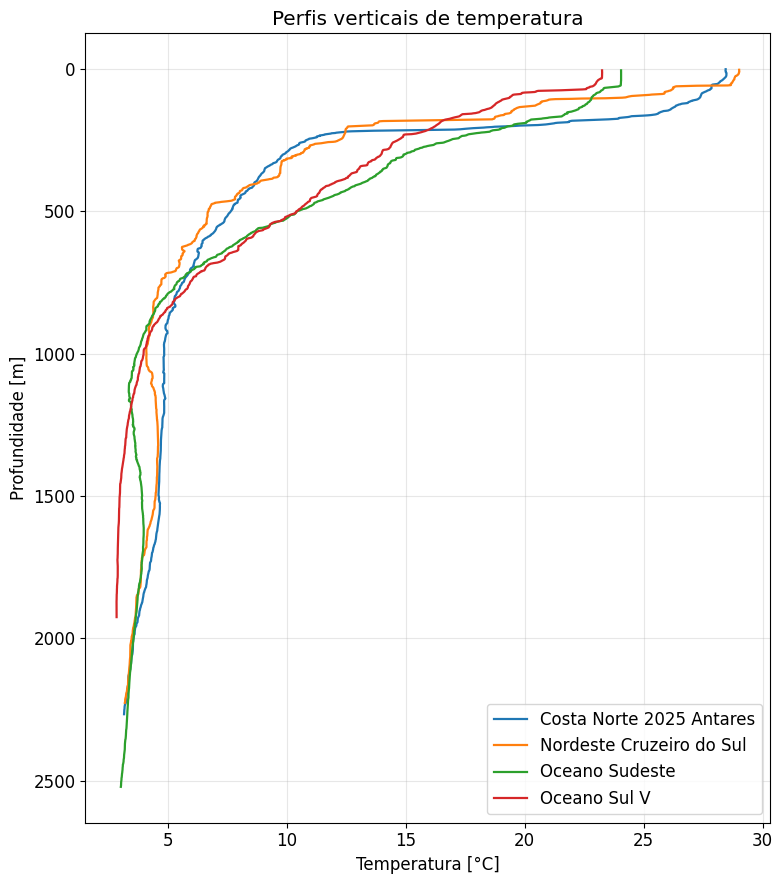

Figura salva em: /content/drive/MyDrive/Acustica_Submarina/Lista_1/figuras/perfil_temperatura.png


In [32]:
plotar_perfis(
    coluna="Temperatura [°c]",
    titulo="Perfis verticais de temperatura",
    eixo_x="Temperatura [°C]",
    nome_arquivo="perfil_temperatura.png"
)

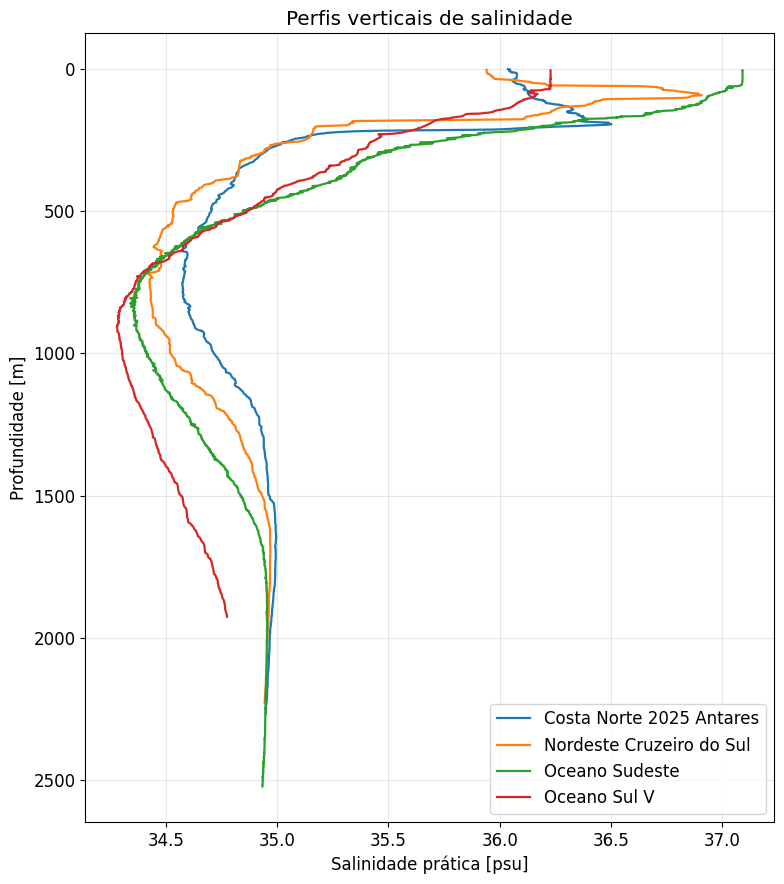

Figura salva em: /content/drive/MyDrive/Acustica_Submarina/Lista_1/figuras/perfil_salinidade.png


In [33]:
plotar_perfis(
    coluna="Salinidade [psu]",
    titulo="Perfis verticais de salinidade",
    eixo_x="Salinidade prática [psu]",
    nome_arquivo="perfil_salinidade.png"
)

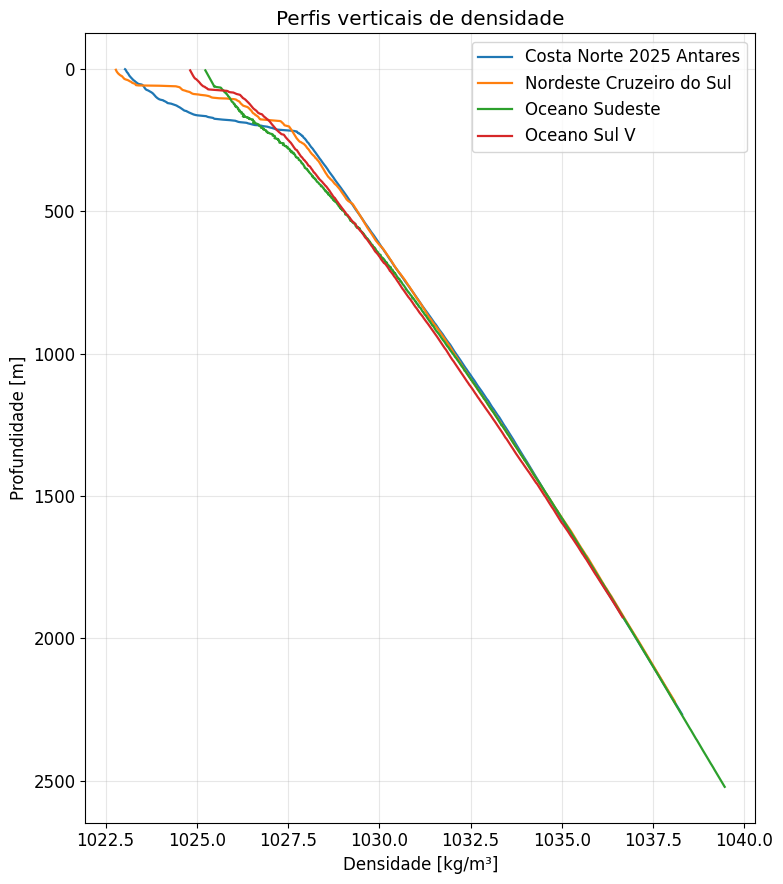

Figura salva em: /content/drive/MyDrive/Acustica_Submarina/Lista_1/figuras/perfil_densidade.png


In [34]:
plotar_perfis(
    coluna="Densidade calculada [kg/m³]",
    titulo="Perfis verticais de densidade",
    eixo_x="Densidade [kg/m³]",
    nome_arquivo="perfil_densidade.png"
)

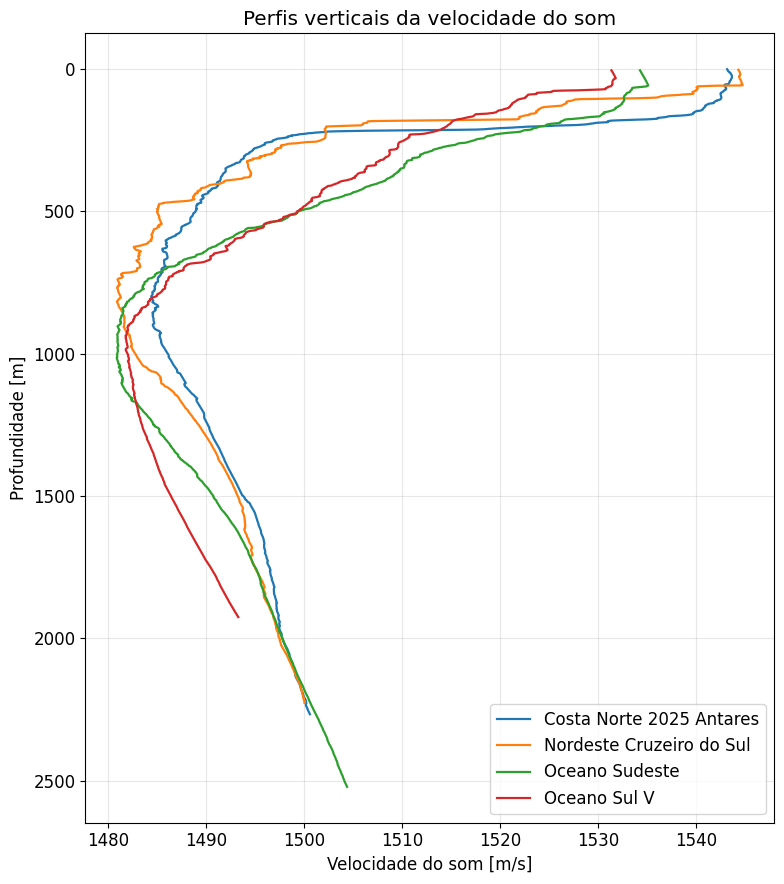

Figura salva em: /content/drive/MyDrive/Acustica_Submarina/Lista_1/figuras/perfil_velocidade_som.png


In [35]:
plotar_perfis(
    coluna="Velocidade do som calculada [m/s]",
    titulo="Perfis verticais da velocidade do som",
    eixo_x="Velocidade do som [m/s]",
    nome_arquivo="perfil_velocidade_som.png"
)

In [36]:
# ============================================================
# Salvar tabelas finais no Google Drive
# ============================================================

caminho_tabela_final = os.path.join(
    PASTA_PROCESSADOS,
    "tabela_resultados_80_200_2000m.csv"
)

caminho_comparacao = os.path.join(
    PASTA_PROCESSADOS,
    "comparacao_medidos_calculados.csv"
)

caminho_perfis = os.path.join(
    PASTA_PROCESSADOS,
    "perfis_identificados.csv"
)

caminho_sul = os.path.join(
    PASTA_PROCESSADOS,
    "resultado_sul_maior_profundidade.csv"
)

tabela_final.to_csv(
    caminho_tabela_final,
    index=False,
    encoding="utf-8-sig"
)

tabela_comparacao.to_csv(
    caminho_comparacao,
    index=False,
    encoding="utf-8-sig"
)

df_perfis.to_csv(
    caminho_perfis,
    index=False,
    encoding="utf-8-sig"
)

tabela_sul_suplementar.to_csv(
    caminho_sul,
    index=False,
    encoding="utf-8-sig"
)

print("Arquivos salvos com sucesso:")
print(caminho_tabela_final)
print(caminho_comparacao)
print(caminho_perfis)
print(caminho_sul)

Arquivos salvos com sucesso:
/content/drive/MyDrive/Acustica_Submarina/Lista_1/dados_processados/tabela_resultados_80_200_2000m.csv
/content/drive/MyDrive/Acustica_Submarina/Lista_1/dados_processados/comparacao_medidos_calculados.csv
/content/drive/MyDrive/Acustica_Submarina/Lista_1/dados_processados/perfis_identificados.csv
/content/drive/MyDrive/Acustica_Submarina/Lista_1/dados_processados/resultado_sul_maior_profundidade.csv


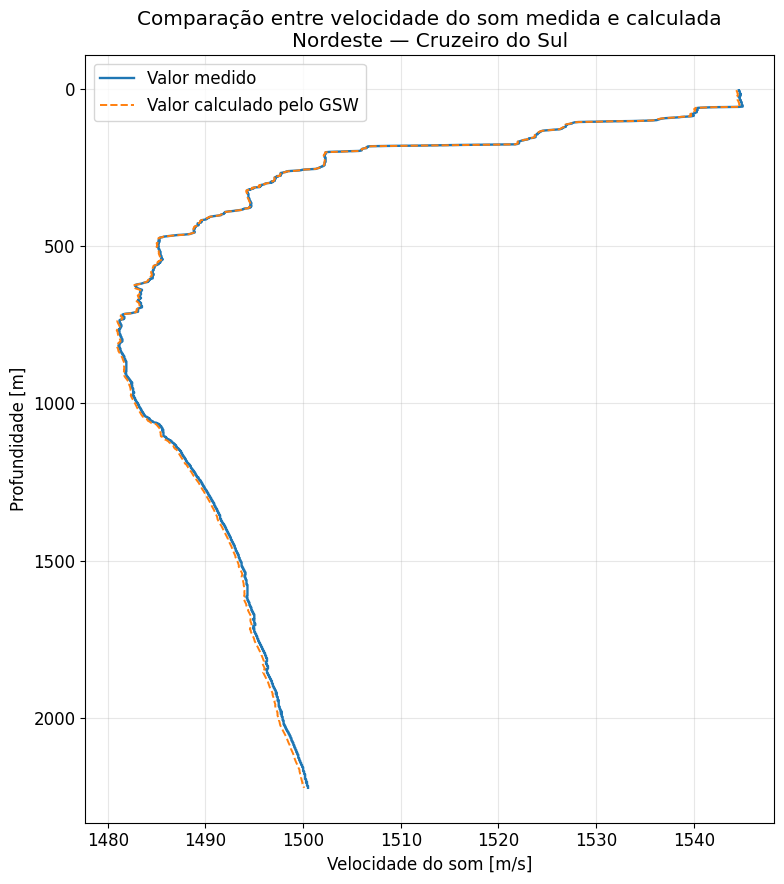

Figura salva em: /content/drive/MyDrive/Acustica_Submarina/Lista_1/figuras/validacao_velocidade_som_nordeste.png


In [37]:
# ============================================================
# Comparação da velocidade do som medida e calculada
# Região Nordeste
# ============================================================

regiao_validacao = "Nordeste Cruzeiro do Sul"
df_validacao = perfis_calculados[regiao_validacao].copy()

mascara = (
    df_validacao["Profundidade [m]"].notna()
    & df_validacao["Velocidade do som [m/s]"].notna()
    & df_validacao["Velocidade do som calculada [m/s]"].notna()
)

plt.figure(figsize=(8, 9))

plt.plot(
    df_validacao.loc[mascara, "Velocidade do som [m/s]"],
    df_validacao.loc[mascara, "Profundidade [m]"],
    label="Valor medido",
    linewidth=1.7
)

plt.plot(
    df_validacao.loc[mascara, "Velocidade do som calculada [m/s]"],
    df_validacao.loc[mascara, "Profundidade [m]"],
    label="Valor calculado pelo GSW",
    linewidth=1.4,
    linestyle="--"
)

plt.gca().invert_yaxis()
plt.xlabel("Velocidade do som [m/s]")
plt.ylabel("Profundidade [m]")
plt.title(
    "Comparação entre velocidade do som medida e calculada\n"
    "Nordeste — Cruzeiro do Sul"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

caminho_validacao_velocidade = os.path.join(
    PASTA_FIGURAS,
    "validacao_velocidade_som_nordeste.png"
)

plt.savefig(
    caminho_validacao_velocidade,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figura salva em:",
    caminho_validacao_velocidade
)

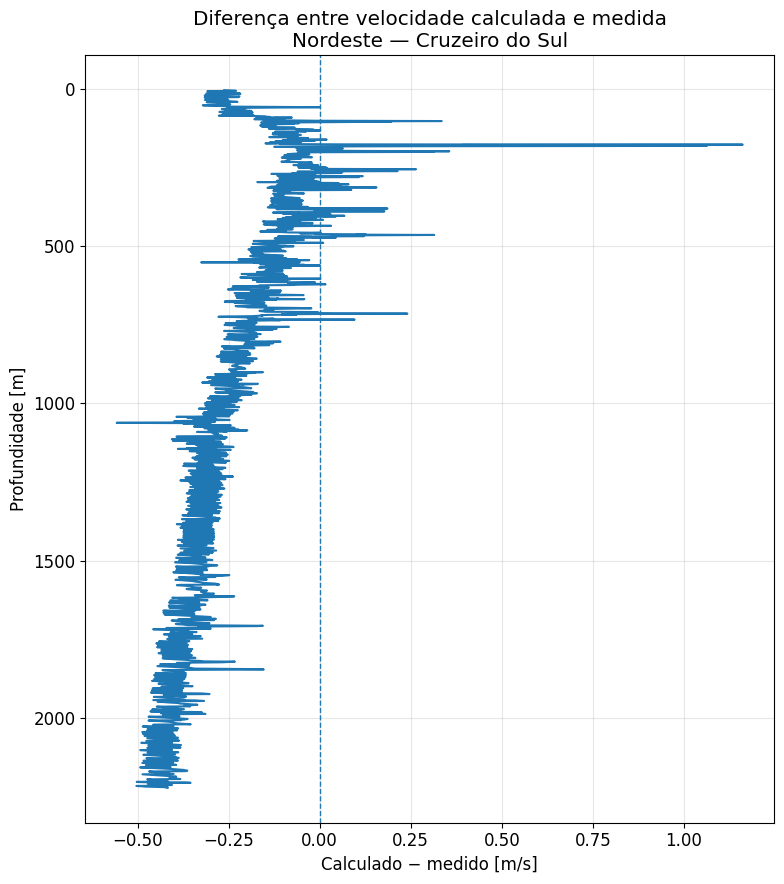

Figura salva em: /content/drive/MyDrive/Acustica_Submarina/Lista_1/figuras/erro_velocidade_som_nordeste.png


In [38]:
# ============================================================
# Diferença entre velocidade calculada e medida
# ============================================================

df_erro_velocidade = df_validacao.loc[
    mascara,
    [
        "Profundidade [m]",
        "Velocidade do som [m/s]",
        "Velocidade do som calculada [m/s]"
    ]
].copy()

df_erro_velocidade["Diferença [m/s]"] = (
    df_erro_velocidade["Velocidade do som calculada [m/s]"]
    - df_erro_velocidade["Velocidade do som [m/s]"]
)

plt.figure(figsize=(8, 9))

plt.plot(
    df_erro_velocidade["Diferença [m/s]"],
    df_erro_velocidade["Profundidade [m]"],
    linewidth=1.5
)

plt.axvline(
    x=0,
    linewidth=1,
    linestyle="--"
)

plt.gca().invert_yaxis()
plt.xlabel("Calculado − medido [m/s]")
plt.ylabel("Profundidade [m]")
plt.title(
    "Diferença entre velocidade calculada e medida\n"
    "Nordeste — Cruzeiro do Sul"
)
plt.grid(True, alpha=0.3)
plt.tight_layout()

caminho_erro_velocidade = os.path.join(
    PASTA_FIGURAS,
    "erro_velocidade_som_nordeste.png"
)

plt.savefig(
    caminho_erro_velocidade,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figura salva em:",
    caminho_erro_velocidade
)